## Demo online con Streamlit

### By: Carlos Javier Palacios Sanchez

### Date: 07/09/2026

### Description:

Requerimiento

- Crear una interfaz web para ingresar los datos requeridos y obtener una predicción
  del modelo.
- Publicar la aplicación en un entorno accesible mediante URL.
- Incluir instrucciones de uso y evidencia de funcionamiento.

---

## Solución

| Entregable | Ruta |
|---|---|
| Aplicación | `src/demo/app.py` |
| Instrucciones | `src/demo/README.md` |
| Pruebas | `tests/demo/test_app.py` |
| Modelo versionado | `models/modelo_corazon_completo.joblib` |
| Dependencias del despliegue | `requirements.txt` (raíz) |
| Evidencia | `notebooks/15. Demo online con Streamlit/evidencia/*.png` |

### Por qué una app nueva y no la del entregable 8

Ya existía una demo en `notebooks/7-deploy/`. Funcionaba, pero llevaba dentro una copia
de los transformadores (`preprocesamiento.py`, 12 KB) y su propio `.joblib`, ambos
heredados de la época en que el proyecto vivía en notebooks.

Con los pipelines de los entregables 9 a 14 ya construidos, mantener esa copia es
exactamente el problema que esos entregables se dedicaron a evitar: dos rutas de
transformación que empiezan iguales y divergen. La app nueva importa el
`inference_pipeline`, que importa el `feature_pipeline`, y no contiene **ni una línea**
de lógica de transformación propia.

```
feature_pipeline.py ──┐
                      ├──> inference_pipeline.py ──> src/demo/app.py
train_pipeline.py ────┘         (predicción por archivo)   (predicción por formulario)
```

Si mañana cambia una regla de saneamiento, la demo se entera sola.

## 1. Configuración

In [2]:
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def localizar_raiz() -> Path:
    """Sube por el árbol de directorios hasta encontrar el pyproject.toml."""
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if (candidato / "pyproject.toml").is_file():
            return candidato
    raise FileNotFoundError("No se encontró la raíz del proyecto")


RAIZ = localizar_raiz()
APP = RAIZ / "src" / "demo" / "app.py"
PRUEBAS = RAIZ / "tests" / "demo"
MODELO = RAIZ / "models" / "modelo_corazon_completo.joblib"
EVIDENCIA = RAIZ / "notebooks" / "15. Demo online con Streamlit" / "evidencia"

sys.path.insert(0, str(RAIZ / "src"))

from demo import app  # noqa: E402
from pipelines.inference_pipeline.inference_pipeline import cargar_modelo  # noqa: E402

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

print(f"Aplicación : {APP.relative_to(RAIZ)}  (existe: {APP.is_file()})")
print(f"Modelo     : {MODELO.relative_to(RAIZ)}  (existe: {MODELO.is_file()})")
print(f"Evidencia  : {len(list(EVIDENCIA.glob('*.png')))} capturas")

Aplicación : src/demo/app.py  (existe: True)
Modelo     : models/modelo_corazon_completo.joblib  (existe: True)
Evidencia  : 3 capturas


## 2. El modelo tiene que estar versionado

Es el detalle que hace fallar la mayoría de los despliegues de este tipo. En local la
app encuentra el modelo en `data/06_models/`, pero **`data/` está en el `.gitignore`**:
ese archivo nunca llega a GitHub, y por tanto tampoco a Streamlit Cloud. La app
desplegada arranca, no encuentra el modelo y muestra un error.

La solución es una copia en `models/`, que sí se versiona. La app busca en las dos
rutas, y `models/` va primero precisamente porque es la que existe en el despliegue.

In [3]:
print("Rutas donde la app busca el modelo, en orden:")
for i, ruta in enumerate(app.RUTAS_MODELO, start=1):
    marca = "✓" if ruta.is_file() else "✗"
    print(f"  {i}. {marca} {ruta.relative_to(RAIZ)}")

print(f"\nRuta elegida: {app.localizar_modelo().relative_to(RAIZ)}")
print(f"Tamaño del artefacto: {MODELO.stat().st_size / 1024:.0f} KB")
print("\nMuy por debajo del límite de GitHub. Si superara 100 MB haría falta Git LFS.")

Rutas donde la app busca el modelo, en orden:
  1. ✓ models/modelo_corazon_completo.joblib
  2. ✓ data/06_models/modelo_corazon_completo.joblib

Ruta elegida: models/modelo_corazon_completo.joblib
Tamaño del artefacto: 170 KB

Muy por debajo del límite de GitHub. Si superara 100 MB haría falta Git LFS.


In [4]:
modelo = cargar_modelo(MODELO)

print("Contexto que viaja con el modelo y se muestra en la barra lateral:\n")
for clave in ("modelo", "generado_en", "version_sklearn", "semilla", "n_train"):
    if clave in modelo.metadatos:
        print(f"  {clave:<18} = {modelo.metadatos[clave]}")
print(f"  {'umbral calibrado':<18} = {modelo.umbral:.2f}")

Contexto que viaja con el modelo y se muestra en la barra lateral:

  modelo             = gradient_boosting
  generado_en        = 2026-09-07T03:07:59+00:00
  version_sklearn    = 1.9.0
  semilla            = 42
  n_train            = 384
  umbral calibrado   = 0.31


La versión de scikit-learn no es un dato decorativo. En `requirements.txt` está fijada
con `==` y no con `>=`:

```
scikit-learn==1.9.0
```

El modelo se serializó con `joblib`, que guarda objetos de Python. Cargarlo con otra
versión puede fallar o —peor— funcionar y comportarse distinto. Al mostrarla en la
barra lateral, cualquiera puede comprobar de un vistazo que la app desplegada está
usando el mismo scikit-learn con el que se entrenó.

## 3. La app no transforma nada por su cuenta

Esta celda es la comprobación de que el formulario y el archivo CSV recorren el mismo
camino: se compara el resultado de la app con el del `inference_pipeline` invocado
explícitamente.

In [5]:
from pipelines.inference_pipeline.inference_pipeline import (
    COLS_REQUERIDAS,
    alinear_columnas,
    predecir,
    transformar,
)

datos = app.EJEMPLOS["Caso intermedio"]

# Camino de la app
por_la_app = app.predecir_paciente(modelo, datos, modelo.umbral)

# Camino explícito del pipeline, tal como lo haría un CSV
crudo = pd.DataFrame([{col: str(datos[col]) for col in COLS_REQUERIDAS}])
por_el_pipeline = predecir(
    modelo, alinear_columnas(transformar(crudo), modelo), umbral=modelo.umbral
).iloc[0]

print(f"Probabilidad vía formulario : {por_la_app['probabilidad_enfermedad']:.6f}")
print(f"Probabilidad vía pipeline   : {por_el_pipeline['probabilidad_enfermedad']:.6f}")
print(
    f"\n¿Idénticas?: {por_la_app['probabilidad_enfermedad'] == por_el_pipeline['probabilidad_enfermedad']}"
)

Probabilidad vía formulario : 0.598500
Probabilidad vía pipeline   : 0.598500

¿Idénticas?: True


## 4. Los tres casos de ejemplo

La app trae tres perfiles precargados para poder probarla sin teclear 13 campos. Aquí
se muestran los tres resultados que producirá la interfaz.

In [6]:
filas = []
for nombre, ejemplo in app.EJEMPLOS.items():
    resultado = app.predecir_paciente(modelo, ejemplo, modelo.umbral)
    senales = sum(1 for _, presente in app.senales_de_riesgo(ejemplo) if presente)
    filas.append(
        {
            "caso": nombre,
            "probabilidad": float(resultado["probabilidad_enfermedad"]),
            "diagnóstico": resultado["diagnostico"],
            "nivel de riesgo": resultado["nivel_riesgo"],
            "señales de riesgo": f"{senales}/4",
        }
    )

pd.DataFrame(filas).set_index("caso").style.format({"probabilidad": "{:.1%}"})

,probabilidad,diagnóstico,nivel de riesgo,señales de riesgo
caso,,,,
Perfil de bajo riesgo,0.6%,sano,muy bajo,0/4
Perfil de alto riesgo,97.5%,enfermo,muy alto,4/4
Caso intermedio,59.9%,enfermo,medio,1/4


## 5. Evidencia de funcionamiento

Capturas de la aplicación ejecutándose, tomadas con el modelo real del proyecto.

### Formulario inicial

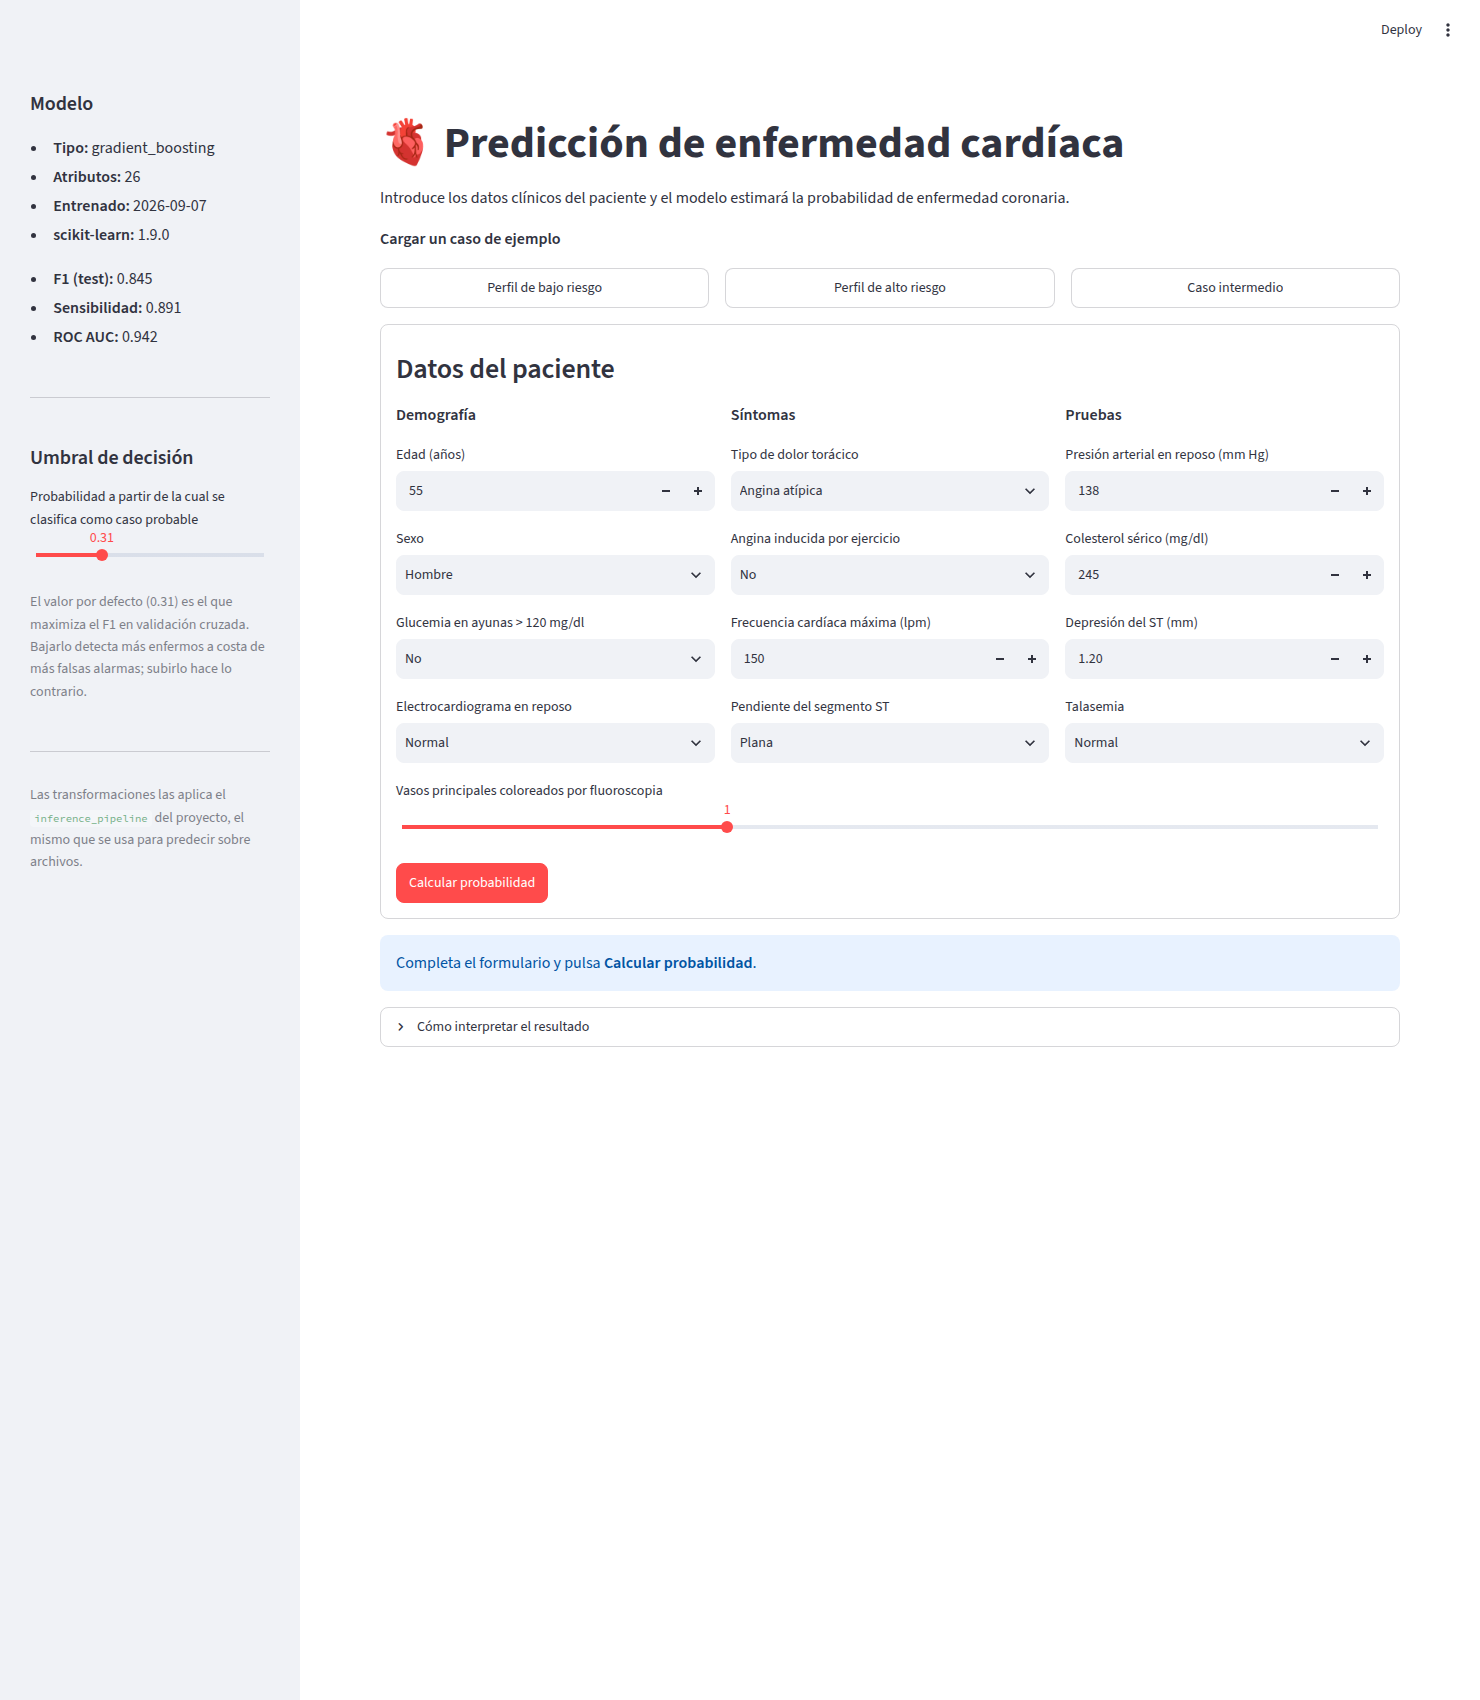

In [7]:
display(Image(filename=str(EVIDENCIA / "01_formulario.png")))

La barra lateral muestra con qué modelo se está prediciendo —tipo, fecha, versión de
scikit-learn y métricas de test— y el control del umbral. El formulario agrupa las 13
variables en demografía, síntomas y pruebas, con los rangos que valida el feature
pipeline: no se puede introducir una edad de 300 años ni una presión de 900 mm Hg.

### Caso de alto riesgo

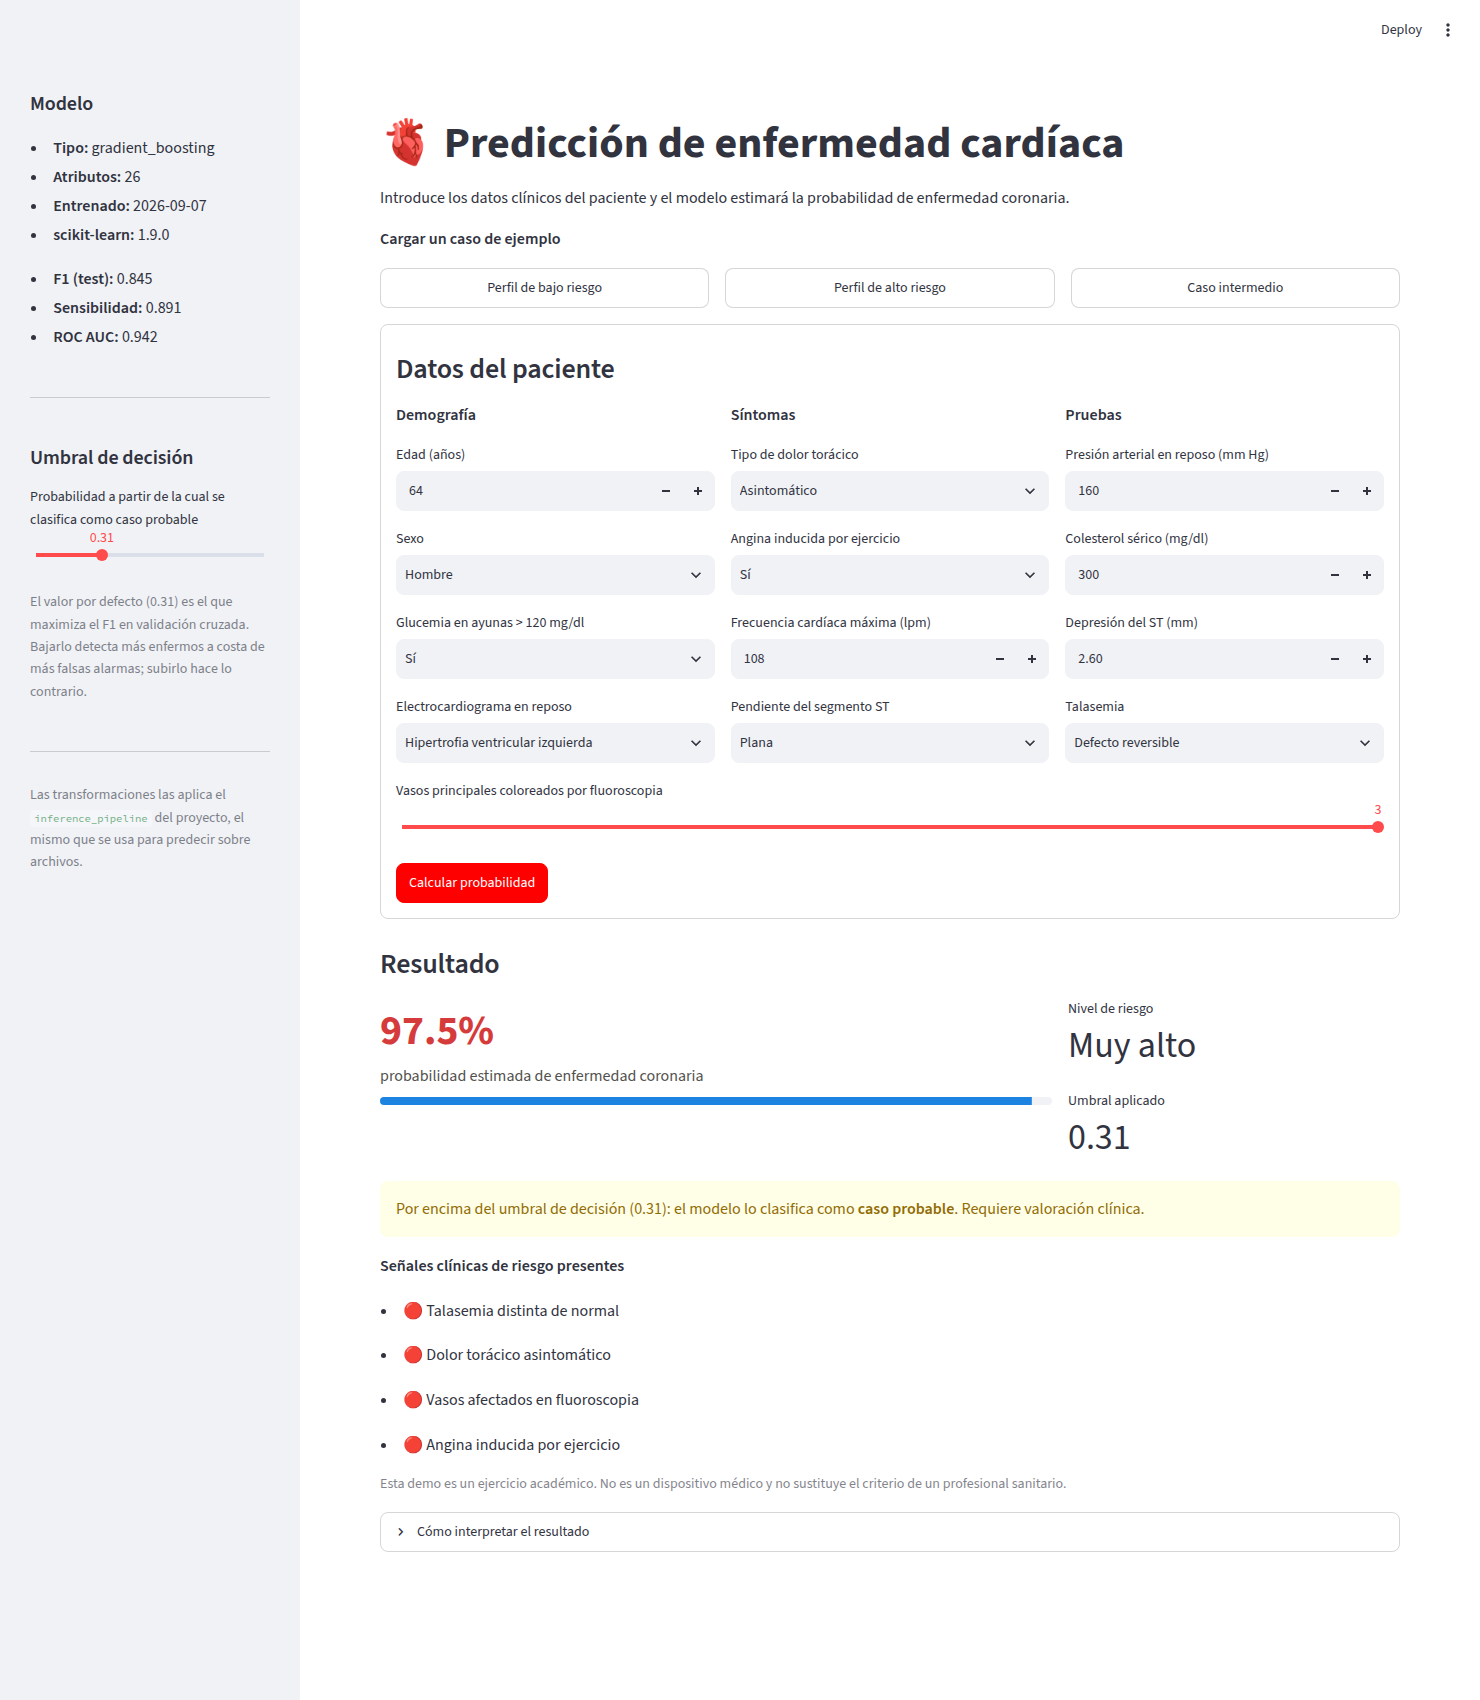

In [8]:
display(Image(filename=str(EVIDENCIA / "02_alto_riesgo.png")))

Probabilidad del 97.5 %, banda "muy alto" y las cuatro señales clínicas presentes. El
mensaje avisa de que supera el umbral y recomienda valoración clínica.

### Caso de bajo riesgo

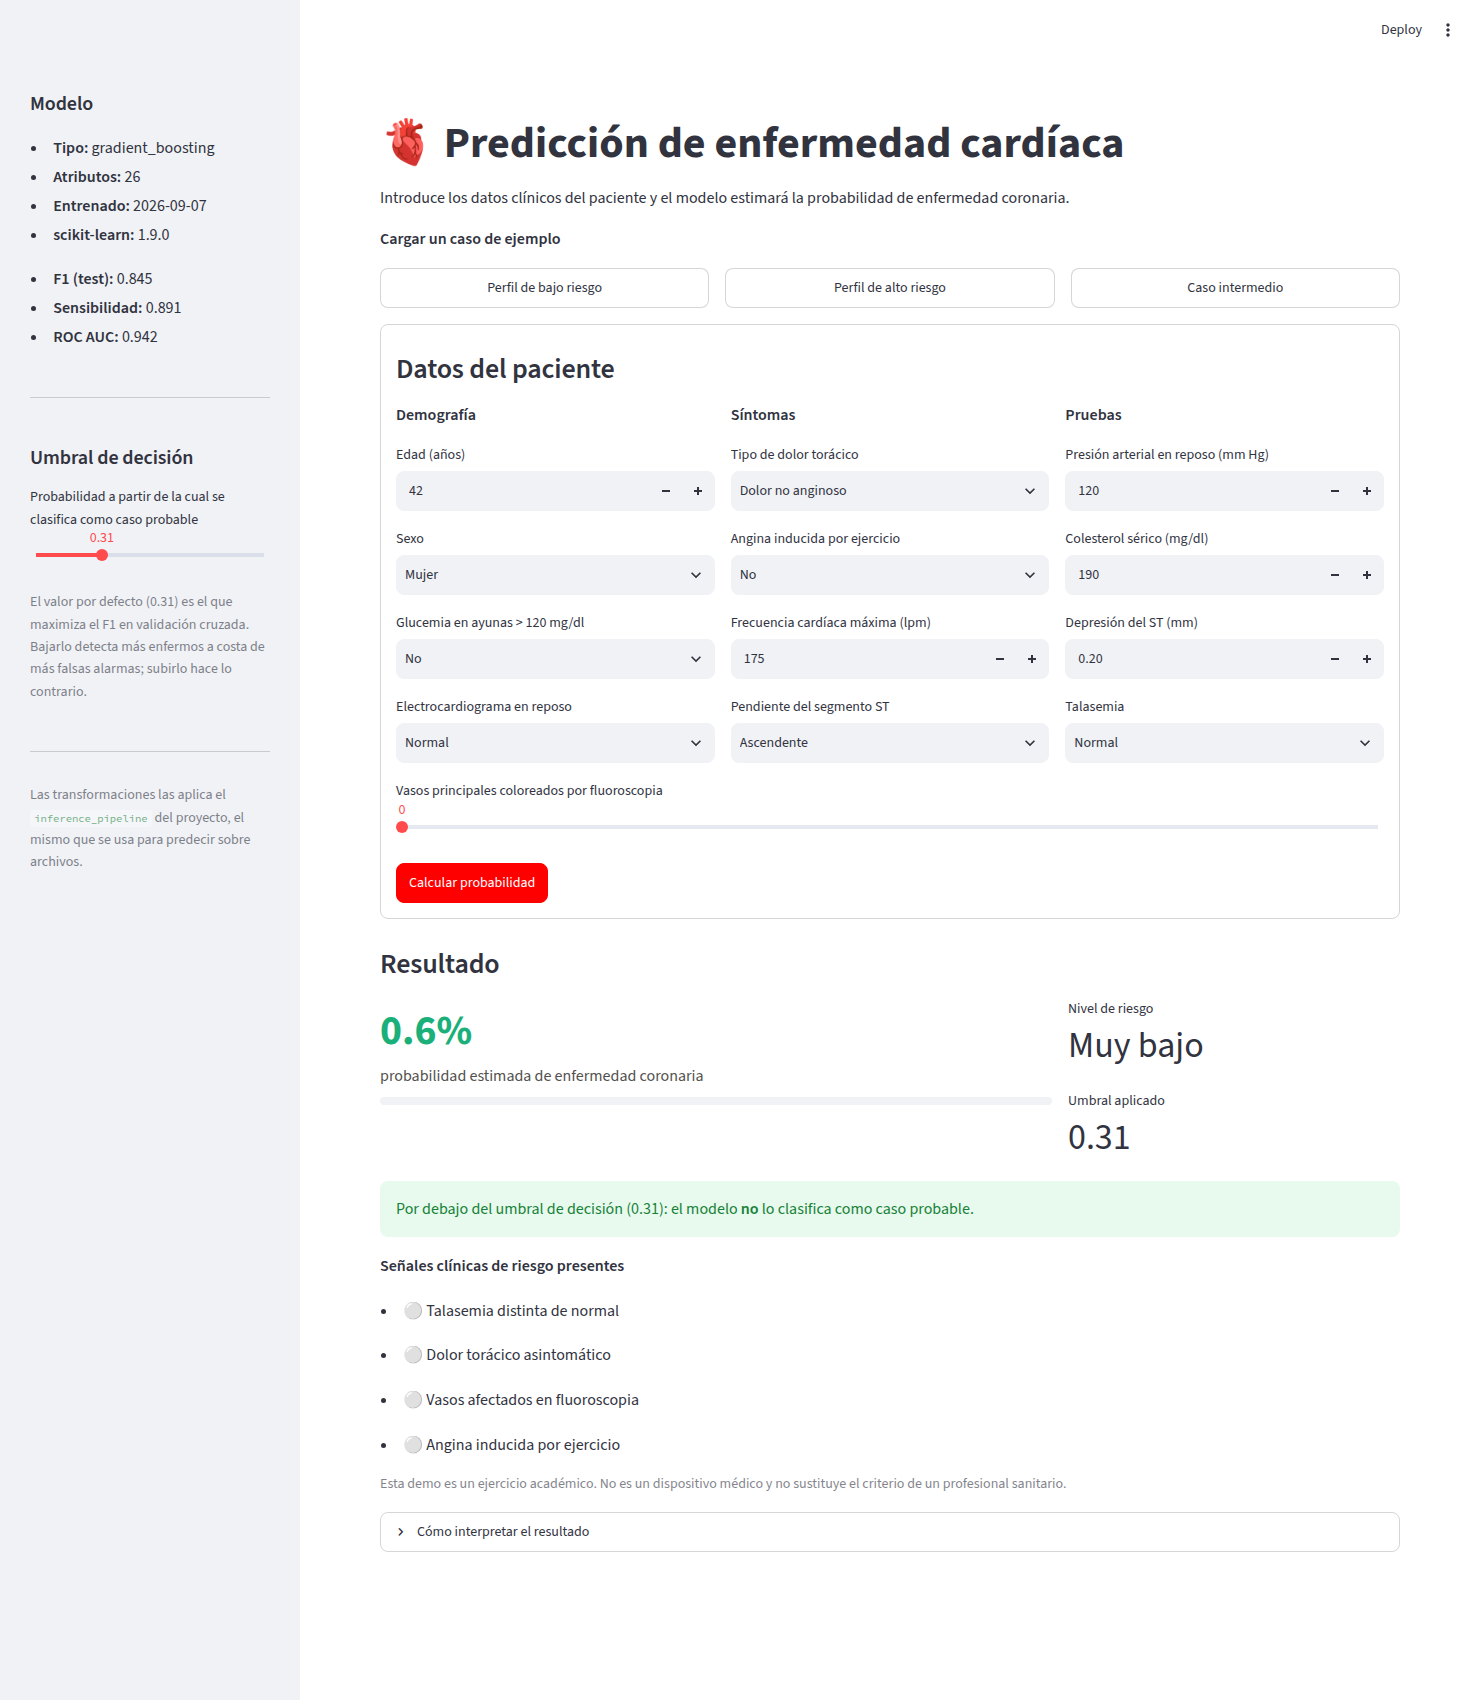

In [9]:
display(Image(filename=str(EVIDENCIA / "03_bajo_riesgo.png")))

El mismo modelo, el mismo umbral, un perfil distinto: 0.6 % de probabilidad y ninguna
señal de riesgo. Que los dos extremos den resultados tan separados es lo que se espera
de un modelo con ROC AUC de 0.94.

## 6. Instrucciones de uso

### Ejecutar en local

```bash
uv pip install -r requirements.txt
uv run streamlit run src/demo/app.py
```

Se abre en <http://localhost:8501>.

### Cómo se usa la interfaz

1. **Elige un caso de ejemplo** (opcional) con uno de los tres botones superiores, o
   rellena el formulario a mano.
2. **Ajusta el umbral** en la barra lateral si quieres ver cómo cambia la decisión. El
   valor por defecto (0.31) es el calibrado en validación cruzada.
3. **Pulsa "Calcular probabilidad"**.
4. **Lee el resultado**: la probabilidad es lo que estima el modelo; el veredicto es esa
   probabilidad comparada con el umbral, y el umbral es una decisión tuya, no del
   modelo.

### Publicar en Streamlit Community Cloud

```bash
git add models/modelo_corazon_completo.joblib requirements.txt src/demo/
git commit -m "feat: demo online con Streamlit sobre el inference pipeline"
git push
```

Después, en <https://share.streamlit.io>:

| Campo | Valor |
|---|---|
| Repository | `CarlosP1005/Heart_project` |
| Branch | la rama de este entregable, o `main` tras el merge |
| Main file path | `src/demo/app.py` |

Streamlit Cloud instala `requirements.txt` automáticamente y publica la app en una URL
con el formato `https://<algo>.streamlit.app`.

> **Pega aquí la URL pública una vez desplegada**, para que quede en el entregable.

## 7. Pruebas

In [10]:
pruebas = subprocess.run(  # noqa: S603
    [sys.executable, "-m", "pytest", str(PRUEBAS), "-v", "--no-header"],
    cwd=RAIZ,
    capture_output=True,
    text=True,
    check=False,
)

print(pruebas.stdout[-4000:])
print(f"Código de salida: {pruebas.returncode}")

============================= test session starts ==============================
collecting ... collected 17 items

tests/demo/test_app.py::test_localizar_modelo_prefiere_models_versionado PASSED [  5%]
tests/demo/test_app.py::test_localizar_modelo_devuelve_una_ruta_existente_o_la_primera PASSED [ 11%]
tests/demo/test_app.py::test_los_ejemplos_traen_todas_las_columnas[Perfil de bajo riesgo] PASSED [ 17%]
tests/demo/test_app.py::test_los_ejemplos_traen_todas_las_columnas[Perfil de alto riesgo] PASSED [ 23%]
tests/demo/test_app.py::test_los_ejemplos_traen_todas_las_columnas[Caso intermedio] PASSED [ 29%]
tests/demo/test_app.py::test_los_ejemplos_usan_categorias_validas[Perfil de bajo riesgo] PASSED [ 35%]
tests/demo/test_app.py::test_los_ejemplos_usan_categorias_validas[Perfil de alto riesgo] PASSED [ 41%]
tests/demo/test_app.py::test_los_ejemplos_usan_categorias_validas[Caso intermedio] PASSED [ 47%]
tests/demo/test_app.py::test_los_ejemplos_caen_dentro_de_los_rangos[Perfil de bajo ries

Las pruebas cubren lo que se puede probar sin levantar la interfaz: que la app busque el
modelo primero en `models/` —el error de despliegue más común—, que los tres casos de
ejemplo usen categorías válidas y caigan dentro de los rangos, y que el resultado del
formulario coincida exactamente con el del `inference_pipeline` invocado a mano.

Esa última es la que importa: si alguien mete un atajo de transformación en la app, esa
prueba falla.

## 8. Conclusiones

| Requisito | Dónde se cumple |
|---|---|
| Interfaz web para ingresar datos | `src/demo/app.py`, formulario con las 13 variables |
| Obtener una predicción del modelo | probabilidad, banda de riesgo y veredicto según umbral |
| Publicar en un entorno con URL | `requirements.txt` + modelo en `models/` + pasos en el README |
| Instrucciones de uso | `src/demo/README.md` y la sección 6 de este notebook |
| Evidencia de funcionamiento | tres capturas de la app en ejecución |

Dos decisiones que vale la pena defender:

1. **La demo es un cliente del pipeline, no una reimplementación.** La app pesa lo que
   pesa la interfaz; toda la lógica de datos vive en los pipelines y está cubierta por
   sus propias pruebas. La demo anterior llevaba 12 KB de transformadores copiados que
   ahora no existen.

2. **El modelo se versiona en `models/`, no en `data/`.** Parece un detalle de
   organización y es la diferencia entre que el despliegue funcione o no: `data/` está
   en el `.gitignore` y no llega al servidor. La app busca en las dos rutas, con
   `models/` primero, y hay una prueba que fija ese orden para que nadie lo invierta
   por descuido.